In [1]:
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)

# 1. Load Data & Split

In [4]:
df = pd.read_csv("../dataset//Crop_recommendation.csv")
df = df.drop(columns=[c for c in df.columns if c.lower().startswith('unnamed')])
df.columns = [c.lower() for c in df.columns]

In [5]:
X = df.drop('label', axis=1)
y = df['label']

In [6]:
scaler = joblib.load("../models/scaler.pkl")
selected_features = joblib.load("../models/selected_features.pkl")

In [7]:
X = X[selected_features]
X = X[list(scaler.feature_names_in_)]
X_scaled = scaler.transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Load Models

In [9]:
models = {
    "LogisticRegression": joblib.load("../models/LogisticRegression.pkl"),
    "KNN": joblib.load("../models/KNN.pkl"),
    "DecisionTree": joblib.load("../models/DecisionTree.pkl"),
    "RandomForest": joblib.load("../models/RandomForest.pkl"),
    "SVM": joblib.load("../models/SVM.pkl")
}

# 3. Evaluation Function

In [10]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average='macro')
    rec_macro = recall_score(y_test, y_pred, average='macro')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    prec_micro = precision_score(y_test, y_pred, average='micro')
    rec_micro = recall_score(y_test, y_pred, average='micro')
    f1_micro = f1_score(y_test, y_pred, average='micro')
    
    return {
        "Model": name,
        "Accuracy": acc,
        "Precision_macro": prec_macro,
        "Recall_macro": rec_macro,
        "F1_macro": f1_macro,
        "Precision_micro": prec_micro,
        "Recall_micro": rec_micro,
        "F1_micro": f1_micro
    }

# 4. Evaluation Loop & Reports

LogisticRegression
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.95      0.97        20
      pa

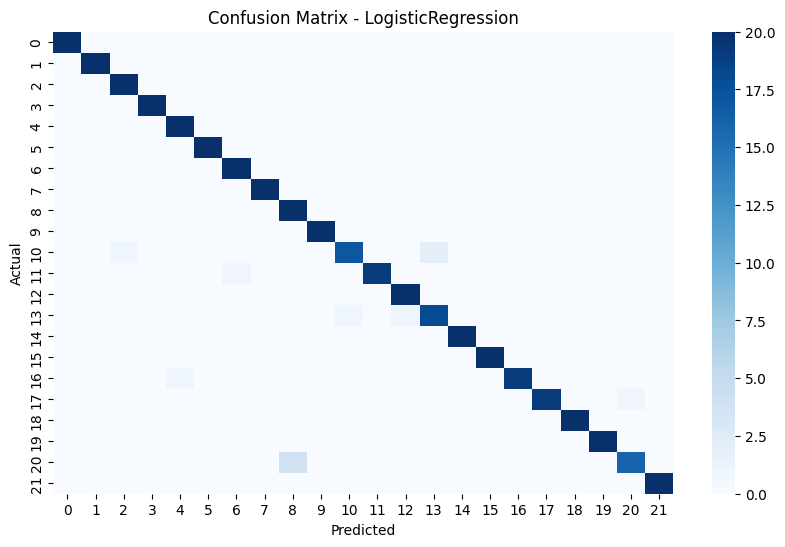

KNN
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.91      1.00      0.95        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.94      0.85      0.89        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.90      0.95        20
      papaya       1.00

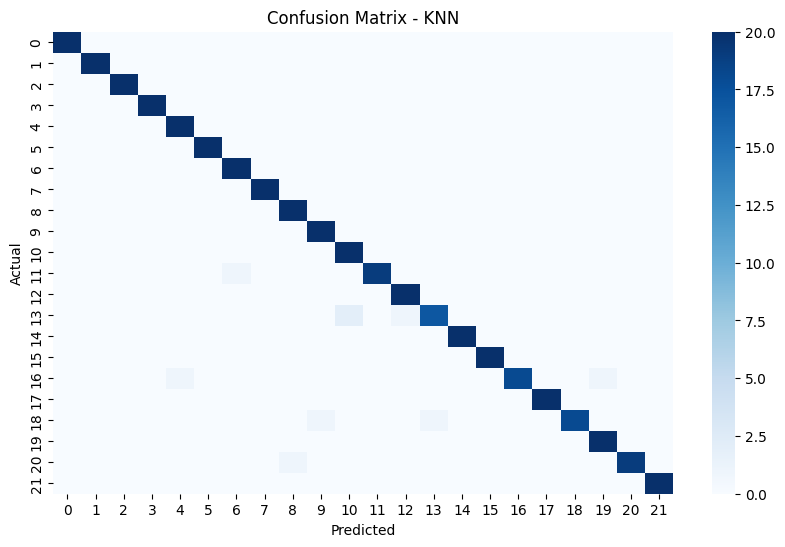

DecisionTree
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.80      0.89        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.86      0.90      0.88        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.86      0.95      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya  

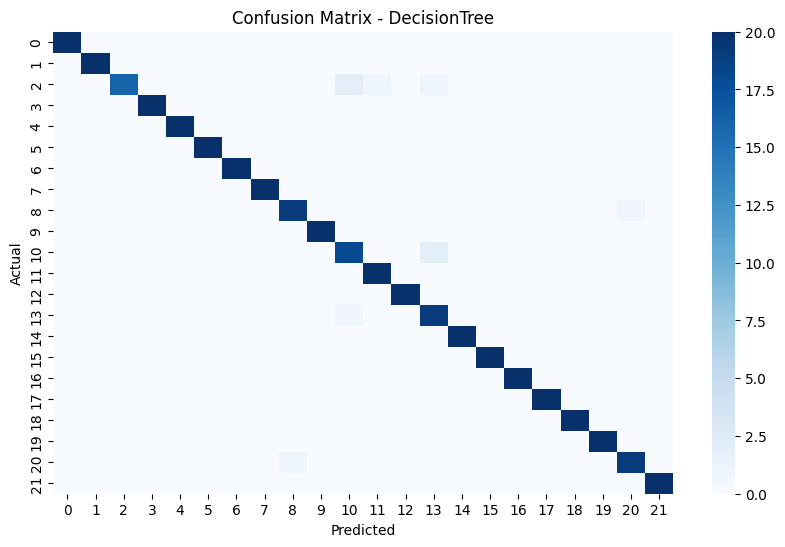

RandomForest
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya  

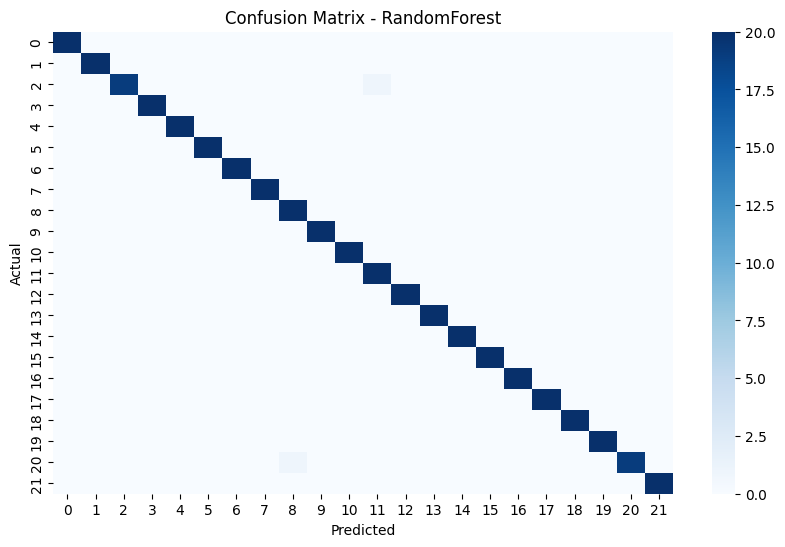

SVM
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.91      1.00      0.95        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      0.90      0.95        20
       mango       0.95      1.00      0.98        20
   mothbeans       1.00      0.95      0.97        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00

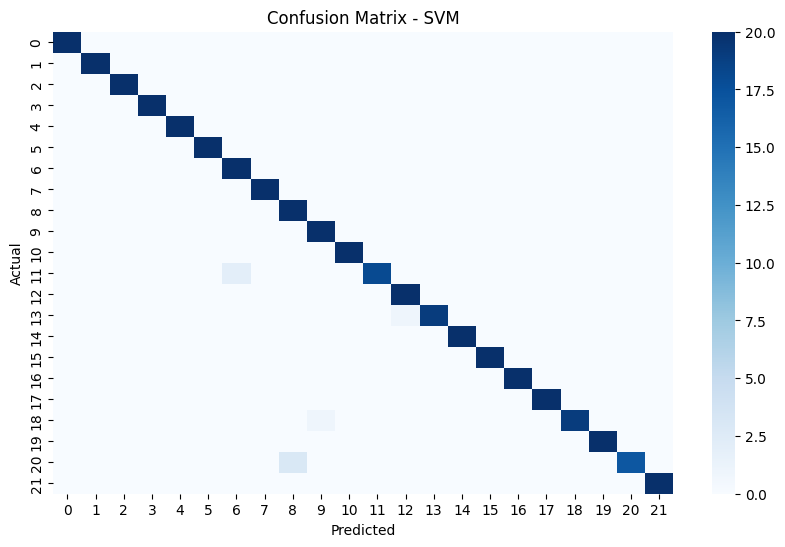

In [11]:
results = []
for name, model in models.items():
    # Store metrics
    res = evaluate_model(name, model, X_test, y_test)
    results.append(res)
    
    # Classification Report
    print("="*50)
    print(name)
    print("="*50)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10,6))
    sns.heatmap(cm, cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# 5. Model Ranking and Selection

In [10]:
results_df = pd.DataFrame(results)
ranking = results_df[['Model','Accuracy','F1_macro','F1_micro']].sort_values(by='F1_macro', ascending=False)
print("Ranking:\n", ranking)

Ranking:
                 Model  Accuracy  F1_macro  F1_micro
3        RandomForest  0.995455  0.995452  0.995455
4                 SVM  0.984091  0.984038  0.984091
2        DecisionTree  0.979545  0.979423  0.979545
1                 KNN  0.979545  0.979283  0.979545
0  LogisticRegression  0.972727  0.972464  0.972727


In [11]:
best_model = results_df.sort_values(by="F1_macro", ascending=False).iloc[0]
print("Best Model Output:\n", best_model)

Best Model Output:
 Model              RandomForest
Accuracy               0.995455
Precision_macro        0.995671
Recall_macro           0.995455
F1_macro               0.995452
Precision_micro        0.995455
Recall_micro           0.995455
F1_micro               0.995455
Name: 3, dtype: object
